In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
#PARAMETER INPUT SIMULASI INVESTASI

modal_awal = 10_000_000        #modal awal
deposit_bulanan = 1_000_000   #deposit/bulan
return_tahunan = 0.08          #return per tahun
tahun = 10                     #waktu investasi

#konversi tahun ke bulan 
jumlah_bulan = tahun * 12
return_bulanan = return_tahunan / 12


#ALGORITMA PERHITUNGAN COMPOUND INTEREST

list_bulan = []
list_total_deposite = []
list_nilai_portofolio = []

total_setoran = modal_awal
nilai_portofolio = modal_awal

for b in range(1, jumlah_bulan + 1):
    #menghitung pertumbuhan dengan bunga bulanan
    nilai_portofolio = (nilai_portofolio + deposite_bulanan) * (1 + return_bulanan)
    total_setoran += deposite_bulanan
    
    list_bulan.append(b)
    list_total_deposite.append(total_setoran)
    list_nilai_portofolio.append(nilai_portofolio)

#membuat df hasil simulasi
df_investasi = pd.DataFrame({
    "Bulan": list_bulan,
    "Tahun": np.array(list_bulan) / 12,
    "Total_Deposit": list_total_deposite,
    "Nilai_Portofolio": list_nilai_portofolio
})

#menambah kolom bunga
df_investasi["Total_Keuntungan"] = df_investasi["Nilai_Portofolio"] - df_investasi["Total_Deposit"]

#menampilkan ringkasan data pertahun
print("        RINGKASAN PERTUMBUHAN INVESTASI PER TAHUN      \n")
print(df_investasi[df_investasi["Bulan"] % 12 == 0][["Tahun", "Total_Deposit", "Nilai_Portofolio", "Total_Keuntungan"]].to_string(index=False))

        RINGKASAN PERTUMBUHAN INVESTASI PER TAHUN      

 Tahun  Total_Deposit  Nilai_Portofolio  Total_Keuntungan
   1.0       22000000      2.336292e+07      1.362921e+06
   2.0       34000000      3.783496e+07      3.834957e+06
   3.0       46000000      5.350817e+07      7.508165e+06
   4.0       58000000      7.048224e+07      1.248224e+07
   5.0       70000000      8.886516e+07      1.886516e+07
   6.0       82000000      1.087738e+08      2.677385e+07
   7.0       94000000      1.303350e+08      3.633495e+07
   8.0      106000000      1.536856e+08      4.768561e+07
   9.0      118000000      1.789744e+08      6.097437e+07
  10.0      130000000      2.063621e+08      7.636208e+07


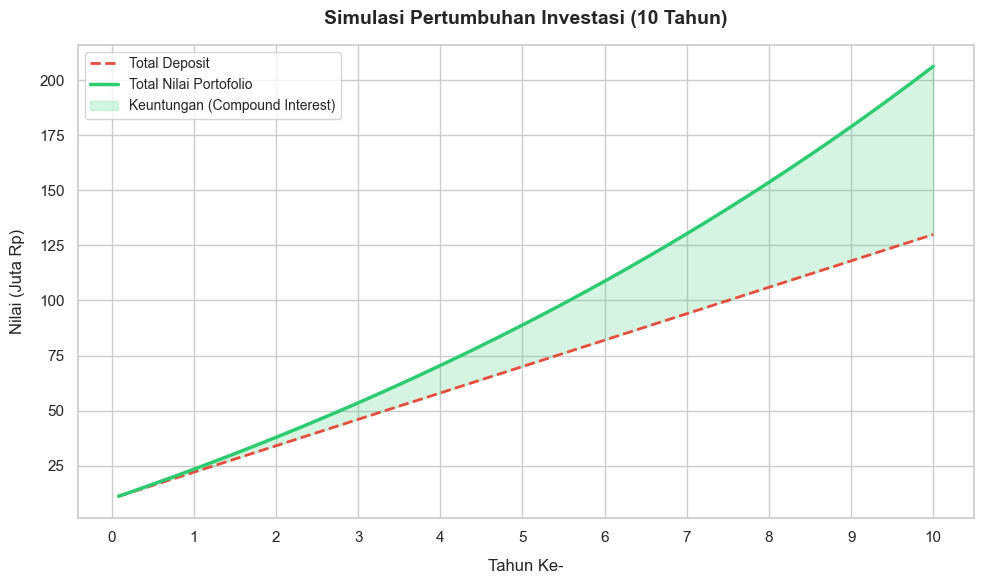

In [19]:
# Set style tampilan
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Konversi nilai ke jutaan Rupiah agar sumbu Y tidak penuh dengan angka nol
tahun_x = df_investasi['Tahun']
setoran_juta = df_investasi['Total_Deposit'] / 1e6
portofolio_juta = df_investasi['Nilai_Portofolio'] / 1e6

# 1. Plot garis Total Setoran (Modal)
plt.plot(tahun_x, setoran_juta, label='Total Deposit', color='#e74c3c', linewidth=2, linestyle='--')

# 2. Plot garis Nilai Portofolio (Modal + Bunga)
plt.plot(tahun_x, portofolio_juta, label='Total Nilai Portofolio', color='#2ecc71', linewidth=2.5)

# 3. Beri warna arsir (Area Chart) untuk memperlihatkan area keuntungan/bunga
plt.fill_between(tahun_x, setoran_juta, portofolio_juta, color='#2ecc71', alpha=0.2, label='Keuntungan (Compound Interest)')

# Formating Grafik
plt.title('Simulasi Pertumbuhan Investasi (10 Tahun)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahun Ke-', fontsize=12, labelpad=10)
plt.ylabel('Nilai (Juta Rp)', fontsize=12, labelpad=10)
plt.xticks(range(0, tahun + 1))  # Sumbu X angka bulat 0 - 10
plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()

# Simpan hasil grafik ke file PNG
plt.savefig('kalkulator_investasi.png', dpi=300, bbox_inches='tight')

# Tampilkan
plt.show()